In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_properties.csv")

df.head()

,property_id,area_sqft,bedrooms,build_year,city,street_type,furnishing,property_type,has_pool,price,is_price_outlier,price_per_sqft,property_age,area_bucket,is_luxury
0,1,2473.19,4,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0,False,229.86,34,2000-2500,False
1,2,2353.47,4,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0,False,245.26,20,2000-2500,False
2,3,2212.22,3,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0,False,262.77,14,2000-2500,False
3,4,2823.89,6,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0,False,281.39,33,2500-3000,False
4,5,1869.65,5,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0,False,263.73,14,1500-2000,False


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (1091, 15)

Columns:
['property_id', 'area_sqft', 'bedrooms', 'build_year', 'city', 'street_type', 'furnishing', 'property_type', 'has_pool', 'price', 'is_price_outlier', 'price_per_sqft', 'property_age', 'area_bucket', 'is_luxury']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1091 entries, 0 to 1090
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       1091 non-null   int64  
 1   area_sqft         1091 non-null   float64
 2   bedrooms          1091 non-null   int64  
 3   build_year        1091 non-null   int64  
 4   city              1091 non-null   object 
 5   street_type       1091 non-null   object 
 6   furnishing        1091 non-null   object 
 7   property_type     1091 non-null   object 
 8   has_pool          1091 non-null   object 
 9   price             1091 non-null   float64
 10  is_price_outlier  1091 non-null   bool   
 11  price_per_sqft    1091 non-null   float64
 12  property_age      1091 non-null   int64  
 13  area_bucket       1091 non-null   object 
 14  is_luxury         1091 non-null   bool   
dtypes: bool(2), float64(3), int64(4), object(6)
memory usage: 113.1+ KB


In [5]:
df.describe()

,property_id,area_sqft,bedrooms,build_year,price,price_per_sqft,property_age
count,1091.000000,1091.000000,1091.000000,1091.000000,1.091000e+03,1091.000000,1091.000000
mean,546.000000,2237.479643,4.567369,2005.124656,6.095736e+05,281.096379,20.875344
std,315.088876,731.097761,1.657288,11.722755,1.438670e+05,47.376882,11.722755
min,1.000000,700.000000,2.000000,1985.000000,2.486400e+05,143.820000,2.000000
25%,273.500000,1834.025000,3.000000,1995.000000,5.177645e+05,249.420000,11.000000
50%,546.000000,2201.550000,5.000000,2005.000000,6.037760e+05,274.170000,21.000000
75%,818.500000,2576.140000,6.000000,2015.000000,6.901470e+05,302.725000,31.000000
max,1091.000000,10267.120000,7.000000,2024.000000,2.071402e+06,537.800000,41.000000


In [6]:
df.isnull().sum()

property_id         0
area_sqft           0
bedrooms            0
build_year          0
city                0
street_type         0
furnishing          0
property_type       0
has_pool            0
price               0
is_price_outlier    0
price_per_sqft      0
property_age        0
area_bucket         0
is_luxury           0
dtype: int64

In [7]:
print("Cities:")
print(df["city"].value_counts())

print("\nProperty Types:")
print(df["property_type"].value_counts())

print("\nFurnishing:")
print(df["furnishing"].value_counts())

print("\nPool:")
print(df["has_pool"].value_counts())

Cities:
city
Noida        150
Kanpur       142
Prayagraj    141
Delhi        139
Lucknow      133
Jaipur       131
Indore       130
Gurugram     125
Name: count, dtype: int64

Property Types:
property_type
Apartment            518
Independent House    317
Duplex               149
Villa                107
Name: count, dtype: int64

Furnishing:
furnishing
Semi-Furnished    436
Furnished         372
Unfurnished       251
Unknown            32
Name: count, dtype: int64

Pool:
has_pool
No     799
Yes    292
Name: count, dtype: int64


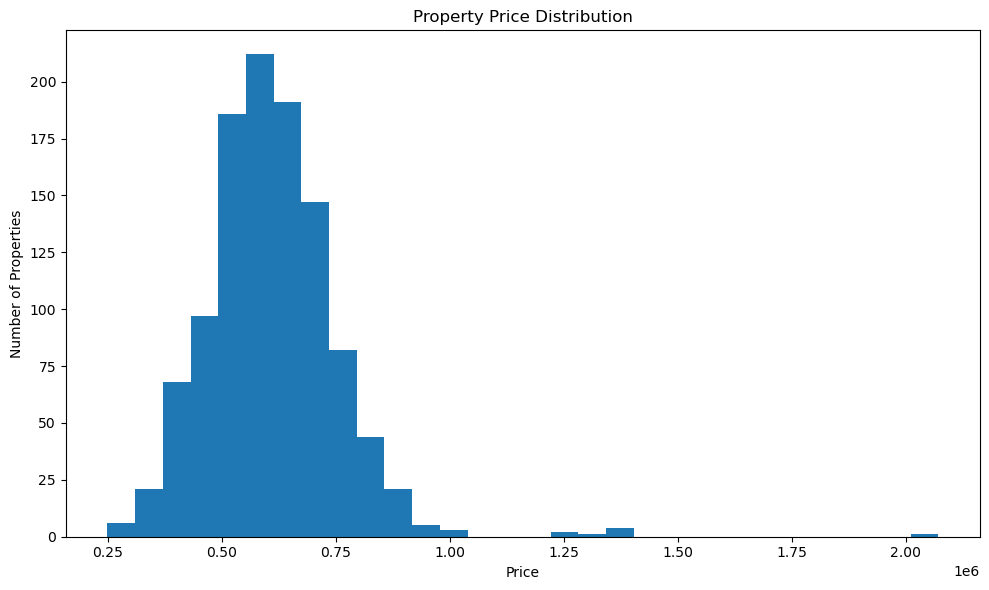

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(df["price"], bins=30)

plt.title("Property Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Properties")

plt.tight_layout()
plt.show()

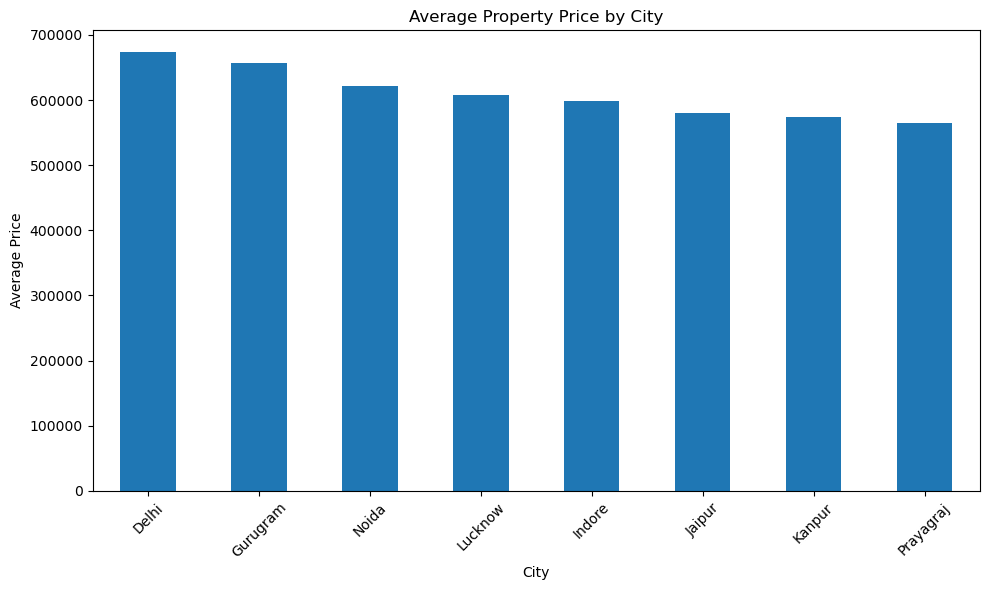

In [9]:
city_price = df.groupby("city")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

city_price.plot(kind="bar")

plt.title("Average Property Price by City")
plt.xlabel("City")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

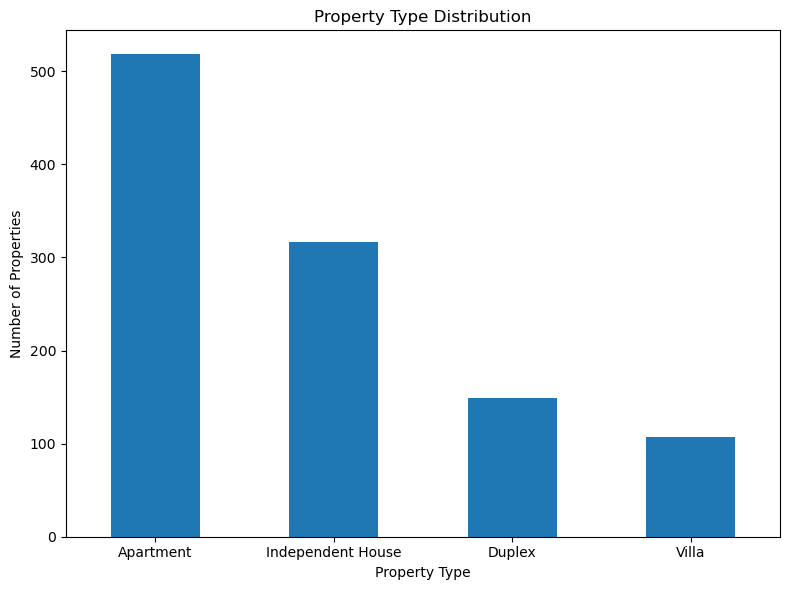

In [10]:
property_counts = df["property_type"].value_counts()

plt.figure(figsize=(8, 6))

property_counts.plot(kind="bar")

plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Number of Properties")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

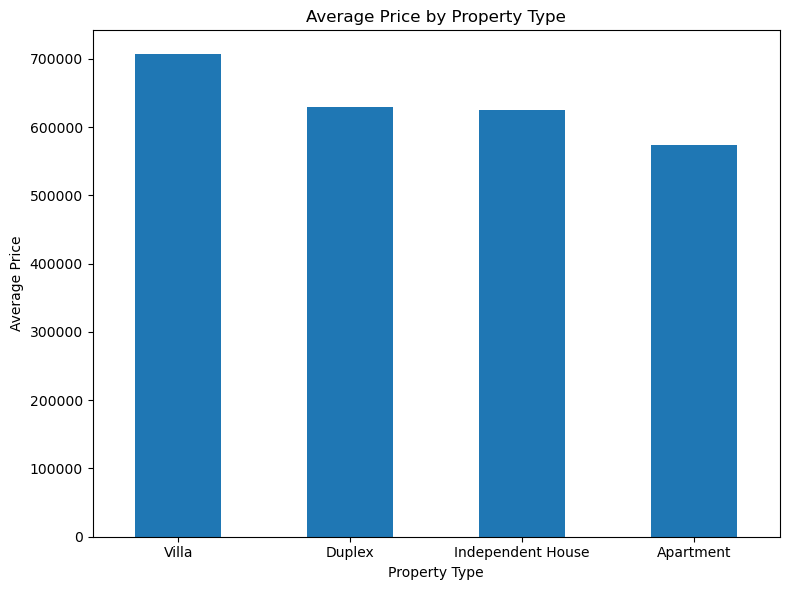

In [11]:
type_price = df.groupby("property_type")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

type_price.plot(kind="bar")

plt.title("Average Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

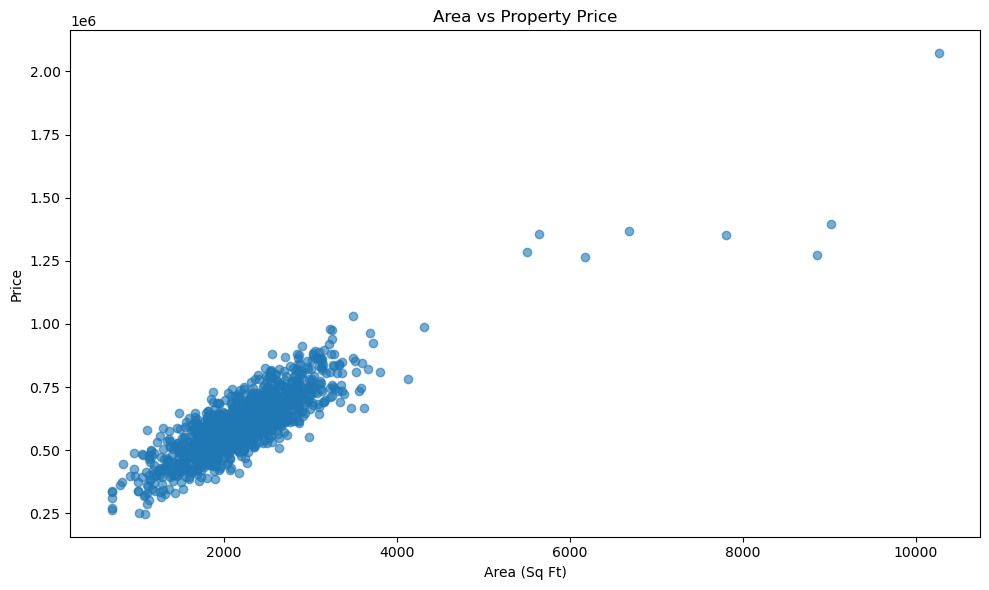

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(df["area_sqft"], df["price"], alpha=0.6)

plt.title("Area vs Property Price")
plt.xlabel("Area (Sq Ft)")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

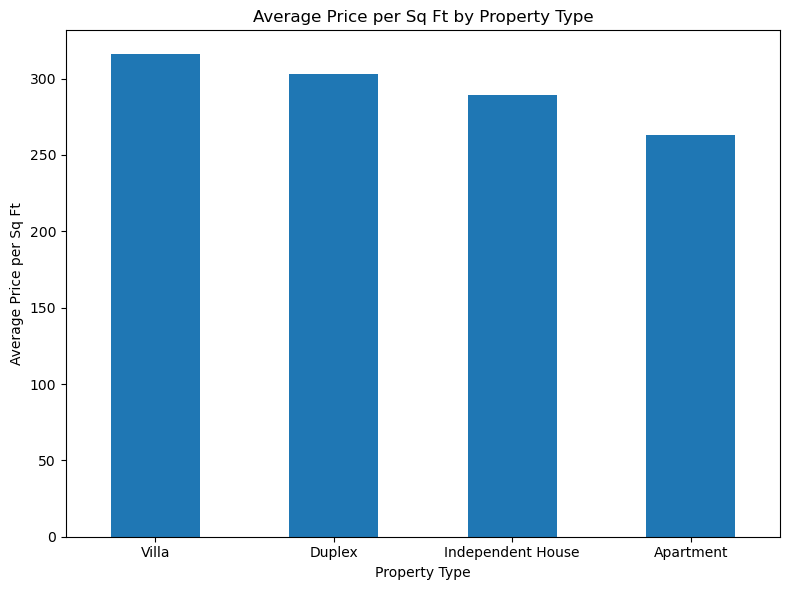

In [13]:
price_sqft_type = df.groupby("property_type")["price_per_sqft"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

price_sqft_type.plot(kind="bar")

plt.title("Average Price per Sq Ft by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price per Sq Ft")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

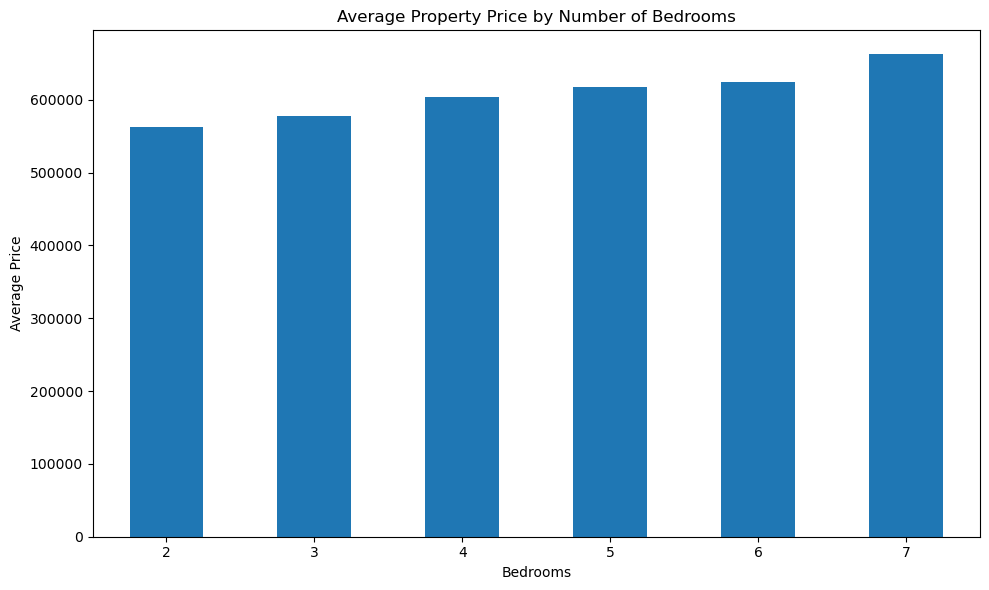

In [14]:
bedroom_price = df.groupby("bedrooms")["price"].mean().sort_index()

plt.figure(figsize=(10, 6))

bedroom_price.plot(kind="bar")

plt.title("Average Property Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

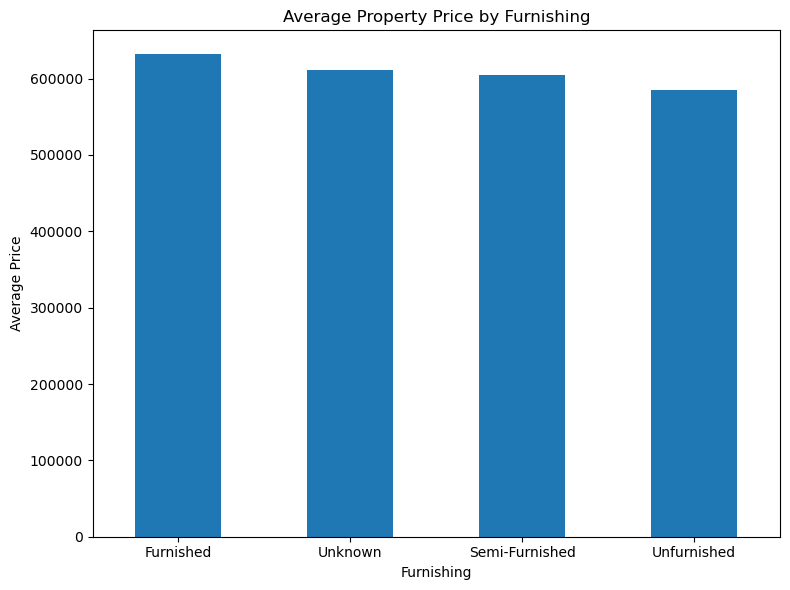

In [15]:
furnishing_price = df.groupby("furnishing")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

furnishing_price.plot(kind="bar")

plt.title("Average Property Price by Furnishing")
plt.xlabel("Furnishing")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

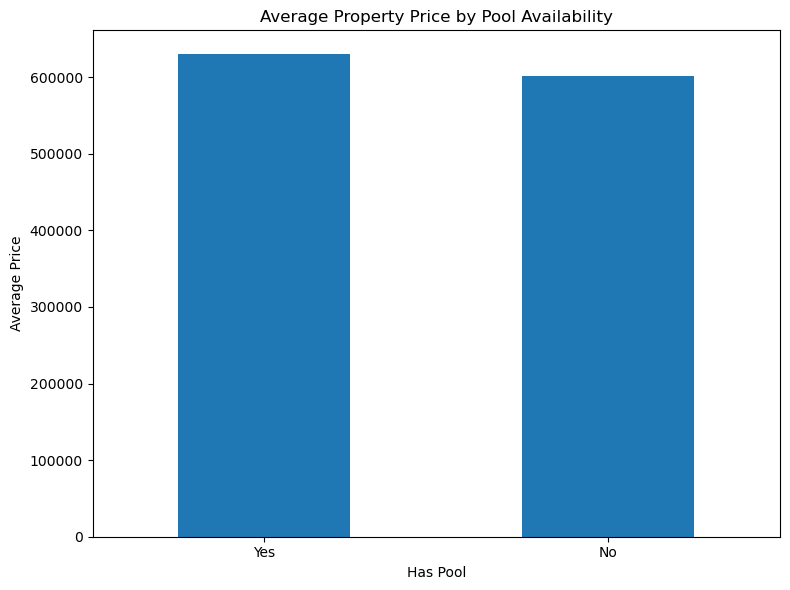

In [16]:
pool_price = df.groupby("has_pool")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))

pool_price.plot(kind="bar")

plt.title("Average Property Price by Pool Availability")
plt.xlabel("Has Pool")
plt.ylabel("Average Price")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

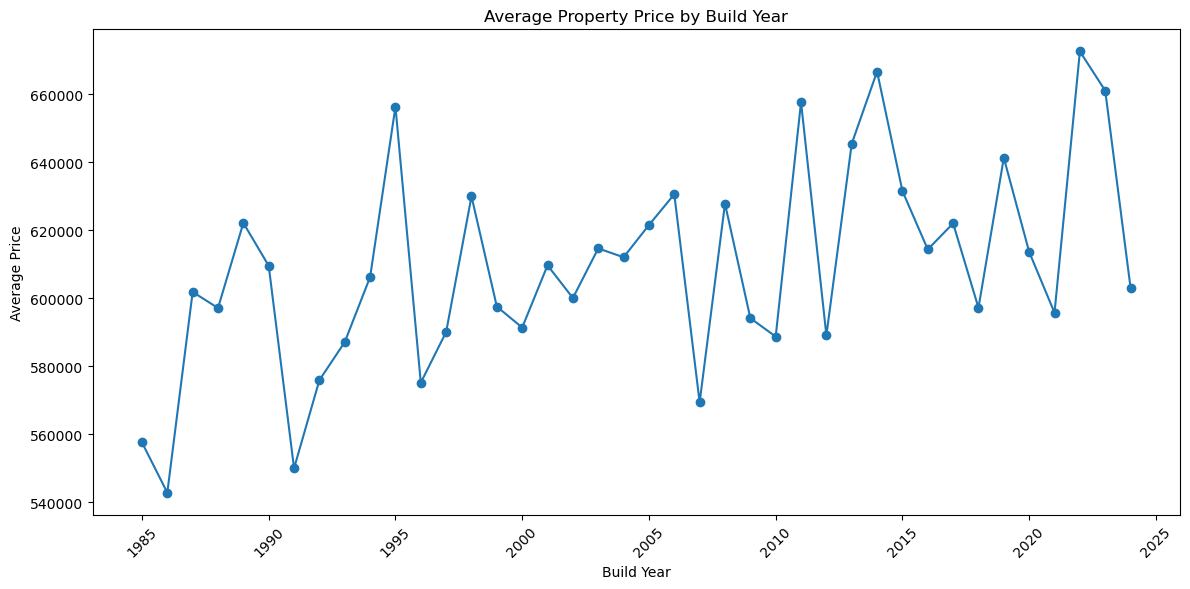

In [17]:
year_price = df.groupby("build_year")["price"].mean().sort_index()

plt.figure(figsize=(12, 6))

year_price.plot(kind="line", marker="o")

plt.title("Average Property Price by Build Year")
plt.xlabel("Build Year")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
correlation = df[["area_sqft", "bedrooms", "build_year", "price", "price_per_sqft"]].corr()

correlation

,area_sqft,bedrooms,build_year,price,price_per_sqft
area_sqft,1.000000,0.027067,0.011755,0.861572,-0.559839
bedrooms,0.027067,1.000000,0.006462,0.214621,0.279218
build_year,0.011755,0.006462,1.000000,0.109973,0.126126
price,0.861572,0.214621,0.109973,1.000000,-0.160102
price_per_sqft,-0.559839,0.279218,0.126126,-0.160102,1.000000


In [19]:
area_price_corr = df["area_sqft"].corr(df["price"])

print("Area vs Price Correlation:", round(area_price_corr, 2))

Area vs Price Correlation: 0.86


In [20]:
area_ppsf_corr = df["area_sqft"].corr(df["price_per_sqft"])

print("Area vs Price per Sq Ft Correlation:", round(area_ppsf_corr, 2))

Area vs Price per Sq Ft Correlation: -0.56


In [21]:
print("Total Properties:", len(df))
print("Average Price:", round(df["price"].mean(), 2))
print("Median Price:", round(df["price"].median(), 2))
print("Average Area:", round(df["area_sqft"].mean(), 2))
print("Average Price per Sq Ft:", round(df["price_per_sqft"].mean(), 2))
print("Maximum Price:", round(df["price"].max(), 2))

Total Properties: 1091
Average Price: 609573.56
Median Price: 603776.0
Average Area: 2237.48
Average Price per Sq Ft: 281.1
Maximum Price: 2071401.84


In [22]:
city_summary = df.groupby("city").agg(
    property_count=("property_id", "count"),
    average_price=("price", "mean"),
    average_area=("area_sqft", "mean"),
    average_price_per_sqft=("price_per_sqft", "mean")
).sort_values("property_count", ascending=False)

city_summary

,property_count,average_price,average_area,average_price_per_sqft
city,,,,
Noida,150,622055.673333,2184.628133,293.430733
Kanpur,142,573733.183099,2209.285915,266.623592
Prayagraj,141,565119.106738,2182.002199,266.055177
Delhi,139,673376.733237,2309.892806,302.486475
Lucknow,133,607860.214962,2273.382406,276.653835
Jaipur,131,580719.104504,2162.457786,278.251221
Indore,130,599002.833000,2327.292308,267.557538
Gurugram,125,657561.224000,2262.001840,297.705920


In [23]:
property_type_summary = df.groupby("property_type").agg(
    property_count=("property_id", "count"),
    average_price=("price", "mean"),
    average_area=("area_sqft", "mean"),
    average_price_per_sqft=("price_per_sqft", "mean")
).sort_values("average_price", ascending=False)

property_type_summary

,property_count,average_price,average_area,average_price_per_sqft
property_type,,,,
Villa,107,706504.023551,2350.205047,315.788131
Duplex,149,628936.632013,2140.923960,302.872819
Independent House,317,625447.956278,2235.311735,289.057886
Apartment,518,574266.920290,2243.295097,262.794247


In [24]:
luxury_count = (df["is_luxury"] == True).sum()

print("Luxury Threshold:", round(df["price"].mean() + 2 * df["price"].std(), 2))
print("Luxury Properties:", luxury_count)
print("Luxury Percentage:", round((luxury_count / len(df)) * 100, 2), "%")

Luxury Threshold: 897307.48
Luxury Properties: 17
Luxury Percentage: 1.56 %
